In [ ]:
%load_ext autoreload
%autoreload 2

import signal
import json
import matplotlib.pyplot as plt
import time
import numpy as np
import pandas as pd
import sys
import os
import tifffile as tiff
from typing import Literal, List
from dataclasses import dataclass

sys.path.append("..")

from main import FlBarProcessor, show_histogram, show_layer_color_histogram

In [ ]:
from scipy.ndimage import rotate
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops

@dataclass
class LayerProp:
    c1_intensity_median: np.float64
    c1_intensity_mean: np.float64
    c1_intensity_max: np.float64
    c1_intensity_min: np.float64
    c1_intensity_center_5pixel: np.float64
    c2_intensity_median: np.float64
    c2_intensity_mean: np.float64
    c2_intensity_max: np.float64
    c2_intensity_min: np.float64
    c2_intensity_center_5pixel: np.float64
    c3_intensity_median: np.float64
    c3_intensity_mean: np.float64
    c3_intensity_max: np.float64
    c3_intensity_min: np.float64
    c3_intensity_center_5pixel: np.float64
    bar_id: int
    area: int
    layer_id: str
    field_name: str
    GroundTruth: int

def filter_bar_mask(img_mask: np.ndarray) -> np.ndarray:

    labeled_mask = label(img_mask)
    regions = regionprops(labeled_mask)

    filtered_mask = np.zeros_like(img_mask)

    for region in regions:
        if (region.axis_minor_length > 0) and (region.axis_major_length/region.axis_minor_length < 3) and (region.area > 2500):
            filtered_mask[labeled_mask == region.label] = region.label
    
    return filtered_mask

def get_layer_props(well_name:str, field:int, ground_truth:int) -> pd.DataFrame:
    img_c1 = tiff.imread(f'path/to/my/file/{well_name}(fld {field} wv Red - Cy5).tif')
    img_c2 = tiff.imread(f'path/to/my/file/{well_name}(fld {field} wv Blue - FITC).tif')
    img_c3 = tiff.imread(f'path/to/my/file/{well_name}(fld {field} wv UV - DAPI).tif')
    img_mask = tiff.imread(f'path/to/my/file/{well_name}(fld {field} wv TL-Brightfield - dsRed)_mask.tif')
    
    img_mask = filter_bar_mask(img_mask)
    masked_img_c3 = img_c3 * (img_mask > 0)
    masked_values_log = np.log1p(masked_img_c3[masked_img_c3 > 0])
    otsu_threshold = threshold_otsu(masked_values_log)

    threshold_mask = np.log1p(img_c3) > otsu_threshold
    layer_mask = img_mask * threshold_mask

    layer_props = []
    for mask_id in np.unique(layer_mask):
        if mask_id == 0:
            continue # Skip background
        ys, xs = np.where(layer_mask == mask_id)
        min_x, max_x = np.min(xs), np.max(xs)
        min_y, max_y = np.min(ys), np.max(ys)
        if min_x == 0 or max_x == layer_mask.shape[1] - 1 or min_y == 0 or max_y == layer_mask.shape[0] - 1:
            continue # Skip touching edges
        area = np.sum(layer_mask == mask_id)
        if area < 100:
            continue # Skip small areas
        

        cropped_layer = layer_mask[min_y:max_y+1, min_x:max_x+1]
        cropped_img_c1 = img_c1[min_y:max_y+1, min_x:max_x+1]
        cropped_img_c2 = img_c2[min_y:max_y+1, min_x:max_x+1]
        cropped_img_c3 = img_c3[min_y:max_y+1, min_x:max_x+1]

        min_area = float('inf')
        best_angle = 0
        for angle in range(0, 180):
            rotated_layer = rotate(cropped_layer, angle, reshape=True, order=0)
            ys, xs = np.where(rotated_layer > 0)
            _area = (np.max(ys) - np.min(ys) + 1) * (np.max(xs) - np.min(xs) + 1)
            if _area < min_area:
                min_area = _area
                best_angle = angle

        best_cropped_layer = rotate(cropped_layer, best_angle, reshape=True, order=0)
        best_ys, best_xs = np.where(best_cropped_layer > 0)
        height = np.max(best_ys) - np.min(best_ys)
        width = np.max(best_xs) - np.min(best_xs)
        if height > width:
            best_cropped_layer = best_cropped_layer.T
            best_angle += 90  
            best_ys, best_xs = best_xs, best_ys

        center_x = np.mean(best_xs).astype(int)
        center_y = np.mean(best_ys).astype(int)

        best_cropped_img_c1 = rotate(cropped_img_c1, best_angle, reshape=True, order=1)
        best_cropped_img_c2 = rotate(cropped_img_c2, best_angle, reshape=True, order=1)
        best_cropped_img_c3 = rotate(cropped_img_c3, best_angle, reshape=True, order=1)

        layer_prop = LayerProp(
            c1_intensity_max=np.max(best_cropped_img_c1[best_cropped_img_c1 > 0]),
            c1_intensity_min=np.min(best_cropped_img_c1[best_cropped_img_c1 > 0]),
            c1_intensity_mean=np.mean(best_cropped_img_c1[best_cropped_img_c1 > 0]),
            c1_intensity_median=np.median(best_cropped_img_c1[best_cropped_img_c1 > 0]),
            c1_intensity_center_5pixel=np.mean(
                best_cropped_img_c1[center_y, center_x-2:center_x+3]),
            c2_intensity_max=np.max(best_cropped_img_c2[best_cropped_img_c2 > 0]),
            c2_intensity_min=np.min(best_cropped_img_c2[best_cropped_img_c2 > 0]),
            c2_intensity_mean=np.mean(best_cropped_img_c2[best_cropped_img_c2 > 0]),
            c2_intensity_median=np.median(best_cropped_img_c2[best_cropped_img_c2 > 0]),
            c2_intensity_center_5pixel=np.mean(
                best_cropped_img_c2[center_y, center_x-2:center_x+3]),
            c3_intensity_max=np.max(best_cropped_img_c3[best_cropped_img_c3 > 0]),
            c3_intensity_min=np.min(best_cropped_img_c3[best_cropped_img_c3 > 0]),
            c3_intensity_mean=np.mean(best_cropped_img_c3[best_cropped_img_c3 > 0]),
            c3_intensity_median=np.median(best_cropped_img_c3[best_cropped_img_c3 > 0]),
            c3_intensity_center_5pixel=np.mean(
                best_cropped_img_c3[center_y, center_x-2:center_x+3]),
            bar_id=mask_id,
            area=area,
            layer_id='Layer 2',
            field_name=f"{well_name}_fld-{field}",
            GroundTruth=ground_truth
        )

        layer_props.append(layer_prop)

    return pd.DataFrame([prop.__dict__ for prop in layer_props])

In [4]:
blurred_field_dict = {
    'A - 1': [1, 5, 9],
    'A - 6': [4],
    'A - 8': [2, 3, 7, 9]
}

In [5]:
dfs = []
well_names = [f"A - {i}" for i in range(1, 10)]
for pos, well_name in enumerate(well_names, start=1):
    blurred_fields = blurred_field_dict.get(well_name, [])
    fields = set(range(1, 10)) - set(blurred_fields)
    for field in fields:
        df_layer_props = get_layer_props(well_name, field, int(well_name[-1]))
        dfs.append(df_layer_props)

In [6]:
df_concat = pd.concat(dfs, ignore_index=True)
df_concat.to_csv('output/single_layer_props_with_gt.csv', index=False)
df_concat

,c1_intensity_median,c1_intensity_mean,c1_intensity_max,c1_intensity_min,c1_intensity_center_5pixel,c2_intensity_median,c2_intensity_mean,c2_intensity_max,c2_intensity_min,c2_intensity_center_5pixel,c3_intensity_median,c3_intensity_mean,c3_intensity_max,c3_intensity_min,c3_intensity_center_5pixel,bar_id,area,layer_id,field_name,GroundTruth
0,107.0,107.199516,121,93,107.6,103.0,103.378476,121,87,102.4,2423.5,3115.194075,7998,240,5924.8,3,1022,Layer 2,A - 1_fld-2,1
1,107.0,107.166667,126,88,106.8,104.0,103.950828,118,86,106.0,2600.5,4191.283126,12854,265,10057.0,4,1170,Layer 2,A - 1_fld-2,1
2,107.0,107.282249,122,92,109.2,104.0,103.630178,116,86,104.4,2500.5,3334.929586,8624,260,7362.0,5,1067,Layer 2,A - 1_fld-2,1
3,107.0,106.536802,120,91,111.0,104.0,103.715102,121,85,110.2,2346.5,2797.446066,6602,277,5287.4,7,1044,Layer 2,A - 1_fld-2,1
4,107.0,106.856275,122,89,108.8,104.0,103.747470,117,78,102.2,3020.0,4717.412449,13524,258,10627.8,10,1287,Layer 2,A - 1_fld-2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10255,6384.5,8144.442473,20852,380,16291.8,2557.5,3327.631720,8611,159,6712.6,3220.5,4188.342473,10730,261,8463.0,164,1193,Layer 2,A - 9_fld-9,9
10256,10545.0,12890.975385,32587,434,31461.4,4248.0,5174.456000,13147,181,12958.0,5316.0,6695.373538,17588,259,17334.2,165,1207,Layer 2,A - 9_fld-9,9
10257,11157.0,10963.268957,22226,388,20417.6,3780.0,3873.802981,7671,166,7194.4,4110.0,4193.979909,8455,230,7618.0,167,1179,Layer 2,A - 9_fld-9,9
10258,15440.0,15798.752641,35042,404,30820.4,7531.0,7664.989434,16696,205,15544.0,8367.0,8652.315103,19706,283,17748.6,169,1377,Layer 2,A - 9_fld-9,9


In [164]:
colors = [
        '#1f77b4',  # Blue
        '#ff7f0e',  # Orange
        '#2ca02c',  # Green
        '#d62728',  # Red
        '#9467bd',  # Purple
        '#8c564b',  # Brown
        '#e377c2',  # Pink
        '#bcbd22',  # Olive
        '#17becf'   # Cyan
    ]

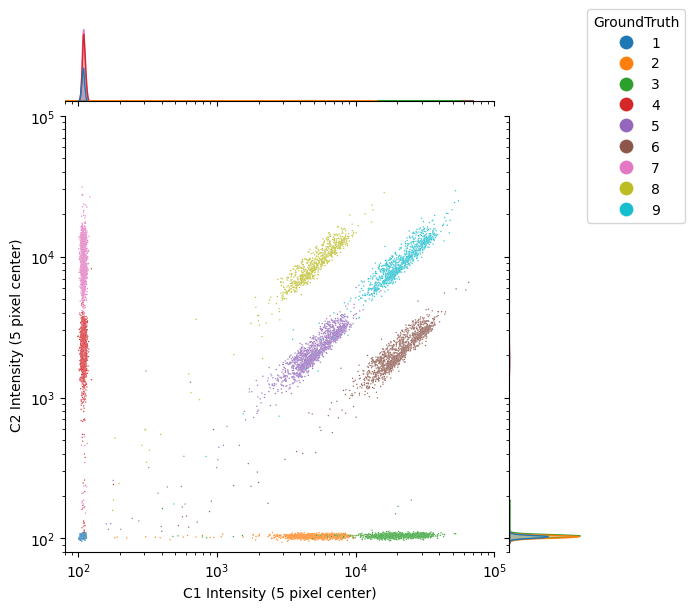

In [169]:
import seaborn as sns

g = sns.jointplot(
    data=df_concat, 
    x='c1_intensity_center_5pixel', 
    y='c2_intensity_center_5pixel', 
    hue='GroundTruth',
    palette=colors,
    s=1)

g.ax_joint.set_xscale('log')
g.ax_joint.set_yscale('log')
g.ax_marg_x.set_yscale('linear')
g.ax_marg_y.set_xscale('linear')

g.set_axis_labels('C1 Intensity (5 pixel center)', 'C2 Intensity (5 pixel center)')

g.ax_joint.set_xlim(8e1, 1e5)
g.ax_joint.set_ylim(8e1, 1e5)
handles, labels = g.ax_joint.get_legend_handles_labels()
g.ax_joint.legend(
    handles=handles, 
    labels=labels, 
    loc='center left', 
    bbox_to_anchor=(1.2, 1), 
    title='GroundTruth', 
    scatterpoints=3, 
    markerscale=10
)